# Evaluación de supuestos de los modelos GARCH

Este notebook evalúa todos los modelos GARCH guardados en `modelos`. El diagnóstico se realiza sobre los **residuos estandarizados**, $z_t = \epsilon_t / \sigma_t$, pues un GARCH bien especificado debe retirar la dependencia tanto de la media como de la varianza condicional.

Se revisan media cero, autocorrelación lineal, autocorrelación en los residuos al cuadrado, efecto ARCH remanente, adecuación de la distribución, convergencia y persistencia de la varianza.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import jarque_bera, kstest, ttest_1samp
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:.4f}")

## Carga e inventario

El inventario permite comprobar el orden de la media AR, el orden GARCH, la distribución elegida por BIC y el estado de convergencia de cada ajuste.

In [2]:
CARPETA_MODELOS = Path("modelos")
rutas_garch = sorted(CARPETA_MODELOS.glob("GARCH_*.joblib"))

if not rutas_garch:
    raise FileNotFoundError(f"No se encontraron modelos GARCH en {CARPETA_MODELOS.resolve()}")

modelos_garch = {
    ruta.stem.removeprefix("GARCH_"): joblib.load(ruta)
    for ruta in rutas_garch
}

print(f"Modelos GARCH encontrados: {len(modelos_garch)}")
print("\n".join(modelos_garch))

Modelos GARCH encontrados: 19
FX_NOKCHF
FX_NZDJPY
FX_ZARJPY
LME_AH_Close
LME_CA_Close
LME_ZS_Close
US_Stock_CLF_adj_close
US_Stock_ENB_adj_close
US_Stock_GLD_adj_close
US_Stock_IAU_adj_close
US_Stock_KMI_adj_close
US_Stock_LYB_adj_close
US_Stock_MS_adj_close
US_Stock_NEM_adj_close
US_Stock_TD_adj_close
US_Stock_TECK_adj_close
US_Stock_VEA_adj_close
US_Stock_VGIT_adj_close
US_Stock_WPM_adj_close


In [3]:
def orden_ar(modelo):
    lags = modelo.model.lags
    return int(np.max(lags)) if lags is not None and np.asarray(lags).size else 0


def persistencia_garch(modelo):
    parametros = modelo.params
    return float(parametros[parametros.index.str.startswith(("alpha[", "beta["))].sum())


def inventario_modelo(nombre, modelo):
    volatilidad = modelo.model.volatility
    return {
        "serie": nombre,
        "orden_AR": orden_ar(modelo),
        "p": volatilidad.p,
        "q": volatilidad.q,
        "distribucion": modelo.model.distribution.name,
        "n_entrenamiento": modelo.nobs,
        "AIC": modelo.aic,
        "BIC": modelo.bic,
        "persistencia": persistencia_garch(modelo),
        "convergence_flag": modelo.convergence_flag,
    }

inventario = pd.DataFrame(
    inventario_modelo(nombre, modelo) for nombre, modelo in modelos_garch.items()
).set_index("serie")
inventario

,orden_AR,p,q,distribucion,n_entrenamiento,AIC,BIC,persistencia,convergence_flag
serie,,,,,,,,,
FX_NOKCHF,2,1,1,Normal,1762,-12664.4168,-12631.5716,0.9800,0
FX_NZDJPY,1,1,1,Normal,1763,-12550.9581,-12523.5843,0.9000,0
FX_ZARJPY,1,1,1,Normal,1763,-11264.5954,-11237.2215,0.6993,0
LME_AH_Close,1,1,1,Normal,1763,-10529.4749,-10502.1010,0.9800,0
LME_CA_Close,1,1,1,Normal,1763,-10552.3696,-10524.9957,0.9000,0
LME_ZS_Close,1,2,1,Standardized Student's t,1763,-9754.2404,-9715.9170,0.9588,9
US_Stock_CLF_adj_close,1,1,1,Standardized Student's t,1763,-7020.9923,-6988.1437,0.9800,0
US_Stock_ENB_adj_close,3,1,2,Standardized Student's t,1761,-10425.8140,-10376.5512,0.9463,0
US_Stock_GLD_adj_close,1,2,1,Standardized Student's t,1763,-11962.6548,-11924.3314,0.9000,0


## Pruebas de diagnóstico

Se omiten las primeras 10 observaciones y los valores no disponibles producidos por los rezagos AR. Con $\alpha=0.05$ se aplican estos criterios:

- Media cero: no rechazar la prueba t sobre residuos estandarizados.
- Sin autocorrelación lineal: no rechazar Ljung-Box para $z_t$.
- Sin dependencia en la varianza: no rechazar Ljung-Box para $z_t^2$ ni ARCH-LM.
- Distribución adecuada: no rechazar uniformidad de la transformación integral de probabilidad (PIT) respecto a la distribución normal o t ajustada.
- Convergencia: `convergence_flag == 0`.
- Varianza estacionaria: persistencia $\sum \alpha_i + \sum \beta_j < 1$.

Jarque-Bera se reporta como referencia, pero no se exige normalidad cuando el modelo fue ajustado con t de Student.

In [4]:
ALFA = 0.05
series_diagnostico = {}

def evaluar_supuestos_garch(nombre, modelo):
    ar = orden_ar(modelo)
    p = modelo.model.volatility.p
    q = modelo.model.volatility.q
    burn_in = max(10, ar + p + q)

    residuos = np.asarray(modelo.resid, dtype=float)[burn_in:]
    residuos_std = np.asarray(modelo.std_resid, dtype=float)[burn_in:]
    volatilidad = np.asarray(modelo.conditional_volatility, dtype=float)[burn_in:]
    validos = np.isfinite(residuos_std) & np.isfinite(residuos) & np.isfinite(volatilidad)
    residuos = residuos[validos]
    residuos_std = residuos_std[validos]
    volatilidad = volatilidad[validos]

    lags_media = [lag for lag in (10, 20, 30) if lag > ar and lag < len(residuos_std)]
    lags_varianza = [lag for lag in (10, 20, 30) if lag > p + q and lag < len(residuos_std)]
    ljung_box = acorr_ljungbox(residuos_std, lags=lags_media, model_df=ar, return_df=True)
    ljung_box_sq = acorr_ljungbox(residuos_std ** 2, lags=lags_varianza, model_df=p + q, return_df=True)

    prueba_media = ttest_1samp(residuos_std, popmean=0.0)
    prueba_jb = jarque_bera(residuos_std)
    prueba_arch = het_arch(residuos_std, nlags=min(20, int(np.sqrt(len(residuos_std)))))

    distribucion = modelo.model.distribution
    nombres_parametros = distribucion.parameter_names()
    parametros_dist = np.asarray([modelo.params[parametro] for parametro in nombres_parametros])
    pit = np.asarray(distribucion.cdf(residuos_std, parametros_dist), dtype=float)
    pit = np.clip(pit, np.finfo(float).eps, 1 - np.finfo(float).eps)
    prueba_pit = kstest(pit, "uniform")

    persistencia = persistencia_garch(modelo)
    series_diagnostico[nombre] = {
        "residuos": residuos,
        "residuos_std": residuos_std,
        "volatilidad": volatilidad,
        "pit": pit,
    }

    resultado = {
        "serie": nombre,
        "n_residuos": len(residuos_std),
        "burn_in": burn_in,
        "media_std": residuos_std.mean(),
        "varianza_std": residuos_std.var(ddof=1),
        "media_p": prueba_media.pvalue,
        "LB_p_min": ljung_box["lb_pvalue"].min(),
        "LB2_p_min": ljung_box_sq["lb_pvalue"].min(),
        "ARCH_p": prueba_arch[1],
        "JB_p": prueba_jb.pvalue,
        "PIT_KS_p": prueba_pit.pvalue,
        "persistencia": persistencia,
        "convergence_flag": modelo.convergence_flag,
        "varianzas_positivas": bool(np.all(volatilidad > 0)),
    }
    for lag, p_valor in ljung_box["lb_pvalue"].items():
        resultado[f"LB_{lag}_p"] = p_valor
    for lag, p_valor in ljung_box_sq["lb_pvalue"].items():
        resultado[f"LB2_{lag}_p"] = p_valor
    return resultado


resultados = pd.DataFrame(
    evaluar_supuestos_garch(nombre, modelo)
    for nombre, modelo in modelos_garch.items()
).set_index("serie")

resultados["media_cero"] = resultados["media_p"] > ALFA
resultados["sin_autocorr_lineal"] = resultados["LB_p_min"] > ALFA
resultados["sin_autocorr_cuadrados"] = resultados["LB2_p_min"] > ALFA
resultados["sin_ARCH"] = resultados["ARCH_p"] > ALFA
resultados["distribucion_adecuada"] = resultados["PIT_KS_p"] > ALFA
resultados["convergencia"] = resultados["convergence_flag"] == 0
resultados["varianza_estacionaria"] = resultados["persistencia"] < 1
resultados

,n_residuos,burn_in,media_std,varianza_std,media_p,LB_p_min,LB2_p_min,ARCH_p,JB_p,PIT_KS_p,persistencia,convergence_flag,varianzas_positivas,LB_10_p,LB_20_p,LB_30_p,LB2_10_p,LB2_20_p,LB2_30_p,media_cero,sin_autocorr_lineal,sin_autocorr_cuadrados,sin_ARCH,distribucion_adecuada,convergencia,varianza_estacionaria
serie,,,,,,,,,,,,,,,,,,,,,,,,,,
FX_NOKCHF,1754,10,-0.0390,1.0592,0.1124,0.1089,0.0281,0.3932,0.0000,0.0321,0.9800,0,True,0.1089,0.3530,0.1968,0.0678,0.1938,0.0281,True,True,False,True,False,True,True
FX_NZDJPY,1754,10,-0.0006,0.9906,0.9798,0.1985,0.3359,0.5502,0.0000,0.0002,0.9000,0,True,0.5701,0.3534,0.1985,0.4694,0.3359,0.7544,True,True,True,True,False,True,True
FX_ZARJPY,1754,10,-0.0198,0.9954,0.4054,0.0510,0.1685,0.4355,0.0000,0.1135,0.6993,0,True,0.0510,0.0936,0.2695,0.1685,0.3204,0.6443,True,True,True,True,True,True,True
LME_AH_Close,1754,10,0.0141,1.0337,0.5623,0.2936,0.6128,0.7275,0.0000,0.3159,0.9800,0,True,0.2936,0.4626,0.6283,0.9271,0.6128,0.7609,True,True,True,True,True,True,True
LME_CA_Close,1754,10,-0.0039,1.0094,0.8715,0.5056,0.6966,0.9786,0.0000,0.0467,0.9000,0,True,0.5056,0.6560,0.8404,0.6966,0.9518,0.8774,True,True,True,True,False,True,True
LME_ZS_Close,1754,10,-0.0096,0.9972,0.6884,0.0846,0.6053,0.9538,0.0000,0.7684,0.9588,9,True,0.6096,0.2865,0.0846,0.6053,0.8772,0.8232,True,True,True,True,True,False,True
US_Stock_CLF_adj_close,1754,10,-0.0071,0.9894,0.7657,0.3519,0.2032,0.4228,0.0000,0.4964,0.9800,0,True,0.3519,0.6499,0.5580,0.2032,0.3289,0.4183,True,True,True,True,True,True,True
US_Stock_ENB_adj_close,1754,10,-0.0548,1.0409,0.0246,0.3444,0.2582,0.9629,0.0000,0.5934,0.9463,0,True,0.3697,0.5067,0.3444,0.2582,0.8680,0.9884,False,True,True,True,True,True,True
US_Stock_GLD_adj_close,1754,10,-0.0033,0.9825,0.8904,0.4639,0.8852,0.9936,0.0000,0.0550,0.9000,0,True,0.4639,0.5854,0.6837,0.8852,0.9660,0.9368,True,True,True,True,True,True,True


## Resumen breve

Las condiciones sobre residuos al cuadrado y ARCH son las más importantes para decidir si la dinámica de volatilidad quedó capturada. La tabla y las listas siguientes identifican directamente los modelos que requieren revisión.

In [5]:
criterios = [
    "media_cero",
    "sin_autocorr_lineal",
    "sin_autocorr_cuadrados",
    "sin_ARCH",
    "distribucion_adecuada",
    "convergencia",
    "varianza_estacionaria",
]
resumen = pd.DataFrame({
    "cumplen": resultados[criterios].sum(),
    "no_cumplen": (~resultados[criterios]).sum(),
    "porcentaje_cumplimiento": 100 * resultados[criterios].mean(),
})
display(resumen)

for criterio in criterios:
    fallan = resultados.index[~resultados[criterio]].tolist()
    detalle = ", ".join(fallan) if fallan else "ninguno"
    print(f"{criterio}: {detalle}")

,cumplen,no_cumplen,porcentaje_cumplimiento
media_cero,17,2,89.4737
sin_autocorr_lineal,16,3,84.2105
sin_autocorr_cuadrados,12,7,63.1579
sin_ARCH,17,2,89.4737
distribucion_adecuada,15,4,78.9474
convergencia,15,4,78.9474
varianza_estacionaria,19,0,100.0000


media_cero: US_Stock_ENB_adj_close, US_Stock_VEA_adj_close
sin_autocorr_lineal: US_Stock_MS_adj_close, US_Stock_TD_adj_close, US_Stock_TECK_adj_close
sin_autocorr_cuadrados: FX_NOKCHF, US_Stock_KMI_adj_close, US_Stock_MS_adj_close, US_Stock_NEM_adj_close, US_Stock_TD_adj_close, US_Stock_TECK_adj_close, US_Stock_VEA_adj_close
sin_ARCH: US_Stock_KMI_adj_close, US_Stock_TD_adj_close
distribucion_adecuada: FX_NOKCHF, FX_NZDJPY, LME_CA_Close, US_Stock_MS_adj_close
convergencia: LME_ZS_Close, US_Stock_LYB_adj_close, US_Stock_TECK_adj_close, US_Stock_VGIT_adj_close
varianza_estacionaria: ninguno


In [6]:
n_modelos = len(resultados)
print("Lectura breve de los resultados:")
print(f"- {resultados['sin_autocorr_lineal'].sum()} de {n_modelos} no presentan autocorrelación lineal residual.")
print(f"- {resultados['sin_autocorr_cuadrados'].sum()} de {n_modelos} no presentan autocorrelación en residuos al cuadrado.")
print(f"- {resultados['sin_ARCH'].sum()} de {n_modelos} no muestran efecto ARCH remanente.")
print(f"- {resultados['distribucion_adecuada'].sum()} de {n_modelos} son compatibles con la distribución ajustada.")
print(f"- {resultados['convergencia'].sum()} de {n_modelos} convergieron correctamente.")
print(f"- {resultados['varianza_estacionaria'].sum()} de {n_modelos} tienen persistencia menor que uno.")
print("- Los modelos sin convergencia deben reajustarse antes de interpretar el resto de sus pruebas.")

Lectura breve de los resultados:
- 16 de 19 no presentan autocorrelación lineal residual.
- 12 de 19 no presentan autocorrelación en residuos al cuadrado.
- 17 de 19 no muestran efecto ARCH remanente.
- 15 de 19 son compatibles con la distribución ajustada.
- 15 de 19 convergieron correctamente.
- 19 de 19 tienen persistencia menor que uno.
- Los modelos sin convergencia deben reajustarse antes de interpretar el resto de sus pruebas.


## Diagnóstico gráfico

Por defecto se muestra el modelo con mayor evidencia de ARCH remanente. Se puede asignar cualquier clave de `modelos_garch` a `NOMBRE_MODELO`.

Modelo mostrado: US_Stock_TD_adj_close


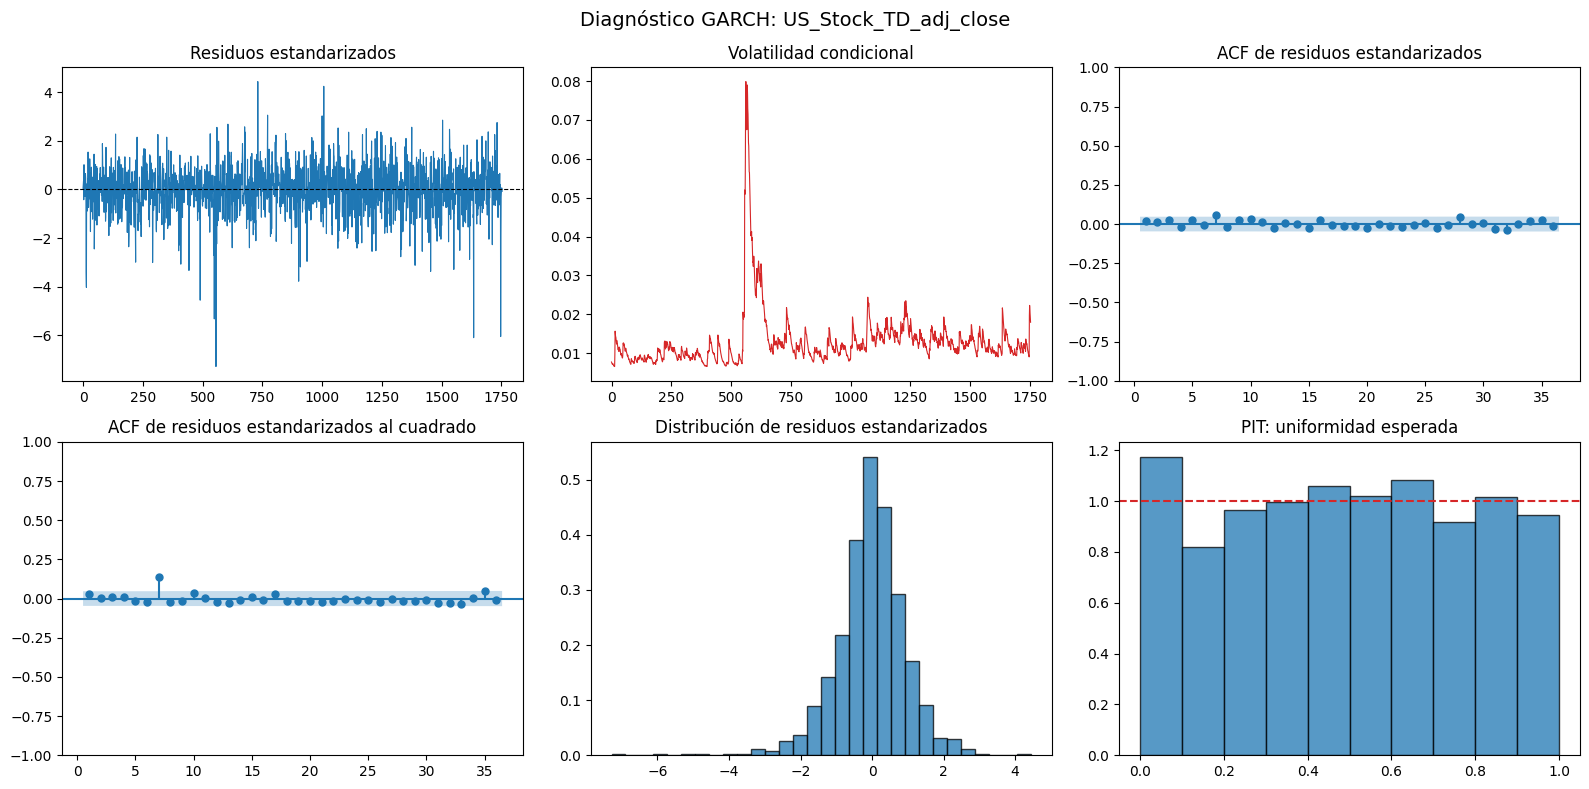

In [7]:
def diagnosticos_graficos(nombre):
    diagnostico = series_diagnostico[nombre]
    residuos_std = diagnostico["residuos_std"]
    volatilidad = diagnostico["volatilidad"]
    pit = diagnostico["pit"]
    max_lags = min(36, len(residuos_std) // 2 - 1)

    fig, ejes = plt.subplots(2, 3, figsize=(16, 8))
    ejes[0, 0].plot(residuos_std, linewidth=0.8)
    ejes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    ejes[0, 0].set_title("Residuos estandarizados")
    ejes[0, 1].plot(volatilidad, color="tab:red", linewidth=0.8)
    ejes[0, 1].set_title("Volatilidad condicional")
    plot_acf(residuos_std, lags=max_lags, ax=ejes[0, 2], zero=False)
    ejes[0, 2].set_title("ACF de residuos estandarizados")
    plot_acf(residuos_std ** 2, lags=max_lags, ax=ejes[1, 0], zero=False)
    ejes[1, 0].set_title("ACF de residuos estandarizados al cuadrado")
    ejes[1, 1].hist(residuos_std, bins=30, density=True, alpha=0.75, edgecolor="black")
    ejes[1, 1].set_title("Distribución de residuos estandarizados")
    ejes[1, 2].hist(pit, bins=10, range=(0, 1), density=True, alpha=0.75, edgecolor="black")
    ejes[1, 2].axhline(1, color="tab:red", linestyle="--")
    ejes[1, 2].set_title("PIT: uniformidad esperada")
    fig.suptitle(f"Diagnóstico GARCH: {nombre}", fontsize=14)
    fig.tight_layout()
    plt.show()

NOMBRE_MODELO = resultados["ARCH_p"].idxmin()
print(f"Modelo mostrado: {NOMBRE_MODELO}")
diagnosticos_graficos(NOMBRE_MODELO)

## Consideraciones finales

- Autocorrelación en $z_t$ indica que la ecuación de media AR puede estar incompleta.
- Autocorrelación en $z_t^2$ o un ARCH-LM significativo indica que el orden GARCH no retiró toda la dinámica de volatilidad.
- Persistencia cercana a uno implica choques de volatilidad duraderos, incluso cuando la condición de estacionariedad se cumple formalmente.
- Un `convergence_flag` distinto de cero invalida la confianza en los parámetros y exige reajustar el modelo.
- La prueba PIT-KS usa parámetros estimados, por lo que su p-valor debe interpretarse como diagnóstico aproximado y junto con el histograma PIT.
- Si quedan asimetrías en la volatilidad, puede compararse GARCH con EGARCH o GJR-GARCH; si falla la distribución, pueden evaluarse innovaciones t asimétricas.